## 11_Enterprise_Model_Training_Pipeline
Explainable AI Credit Risk Decision Platform Integrating Structured Borrower Data, NLP-Driven Text Intelligence, and Macroeconomic Indicators for Transparent Lending Decisions.

#### Reason :
Train and evaluate multiple machine learning models on progressively richerfeature sets to determine whether borrower text and external macroeconomic context improve credit risk prediction while preventing data leakage and ensuring reproducibility.

In [100]:
# STANDARD LIBRARY
# __________________________________________

from __future__ import annotations

import gc
import json
import logging
import warnings
from pathlib import Path
from datetime import datetime

# THIRD-PARTY LIBRARIES
# __________________________________________

import joblib
import numpy as np
import pandas as pd

# SPARSE MATRICES
# _________________________________________

from scipy import sparse
from imblearn.over_sampling import SMOTE

# VISUALISATION
# _________________________________________

import matplotlib.pyplot as plt
import seaborn as sns

# SCIKIT-LEARN
# ____________________________________________

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay)

# XGBOOST
# _____________________________________________

from xgboost import XGBClassifier

# REPRODUCIBILITY
# _____________________________________________

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

In [101]:
# PROJECT PATHS
# ______________________________________________

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"

FEATURE_STORE_DIR = DATA_DIR / "feature_store"

MODEL_DIR = PROJECT_ROOT / "models"

REPORT_DIR = PROJECT_ROOT / "reports"

FIGURE_DIR = REPORT_DIR / "figures"

METRIC_DIR = REPORT_DIR / "metrics"

LOG_DIR = PROJECT_ROOT / "logs"

# CREATE OUTPUT FOLDERS
# ________________________________________________

for folder in [

    MODEL_DIR,

    REPORT_DIR,

    FIGURE_DIR,

    METRIC_DIR,

    LOG_DIR]:
    
    folder.mkdir(parents=True, exist_ok=True)

# TARGET COLUMN
# ________________________________________________________

TARGET = "loan_status"

# MODELS TO TRAIN
# ________________________________________________________

MODELS = {

    "Logistic Regression": LogisticRegression,

    "XGBoost": XGBClassifier}

# DISPLAY OPTIONS
# ________________________________________________________

pd.set_option("display.max_columns", None)

pd.set_option("display.width", 180)

pd.set_option("display.max_colwidth", 100)

# EXECUTION METADATA
# _________________________________________________________

EXECUTION_DATE = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

NOTEBOOK = "11_enterprise_model_training_pipeline"

PROJECT = "Explainable AI Credit Risk Decision Platform"

VERSION = "2.0"

AUTHOR = "Emmanuel Ahadzi"

print(PROJECT)

print("=" * 50)

print(f"Notebook        : {NOTEBOOK}")

print(f"Version         : {VERSION}")

print(f"Execution Date  : {EXECUTION_DATE}")

print(f"Random State    : {RANDOM_STATE}")

print(f"Models          : {', '.join(MODELS.keys())}")

Explainable AI Credit Risk Decision Platform
Notebook        : 11_enterprise_model_training_pipeline
Version         : 2.0
Execution Date  : 2026-07-29 16:28:08
Random State    : 42
Models          : Logistic Regression, XGBoost


In [102]:
# LOGGER ENGINE
# __________________________________________________________________

def get_logger():

    logger = logging.getLogger("ModelTraining")

    if not logger.handlers:

        logger.setLevel(logging.INFO)

        handler = logging.StreamHandler()

        formatter = logging.Formatter(
            "%(asctime)s | %(levelname)s | %(message)s")

        handler.setFormatter(formatter)

        logger.addHandler(handler)

    return logger

logger = get_logger()

In [103]:
# LOAD FEATURE MATRIX
# _____________________________________________________

def load_feature_matrix(matrix_name, file_type="npz"):
  
    logger.info(f"Loading Matrix {matrix_name}...")

    if file_type == "pkl":

        X_train = joblib.load(FEATURE_STORE_DIR / f"matrix_{matrix_name}_train.pkl")

        X_test = joblib.load(FEATURE_STORE_DIR / f"matrix_{matrix_name}_test.pkl")

    else:

        X_train = sparse.load_npz(FEATURE_STORE_DIR / f"matrix_{matrix_name}_train.npz")

        X_test = sparse.load_npz(FEATURE_STORE_DIR / f"matrix_{matrix_name}_test.npz")

    logger.info(f"Matrix {matrix_name} loaded successfully.")

    return X_train, X_test
    return train, test

In [104]:
# SAVE MODEL
# ________________________________________________________

def save_model(model, filename):

    path = MODEL_DIR / filename

    joblib.dump(model, path)

    logger.info(f"Model saved -> {path.name}")

In [105]:
# MODEL EVALUATION
# _________________________________________________

def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    results = {

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1": f1_score(y_test, predictions),

        "ROC_AUC": roc_auc_score(y_test, probabilities)}

    return pd.DataFrame([results])

In [106]:
# CLEAR MEMORY
# _________________________________

def clear_memory(*variables):

    for variable in variables:

        del variable

    gc.collect()

    logger.info("Memory cleared.")

In [123]:
# TRAIN MODEL
#______________________________________

def train_model(model,model_name,X_train,
                
                y_train,X_test,y_test,apply_smote=False):

    logger.info(f"Training {model_name} using {dataset_name}")
    
    logger.info("=" * 80)

    # Apply SMOTE (training data only)
    # __________________________________
    
    if apply_smote:

        logger.info("Applying SMOTE...")

        smote = SMOTE(random_state=RANDOM_STATE)

        X_train,
        
        y_train = smote.fit_resample(X_train,y_train)

        logger.info("SMOTE completed.")

    # Train model
    # _______________________________________________

    model.fit(X_train,y_train)

    logger.info("Training complete.")

    # Evaluate
    # ________________________________________________

    results = evaluate_model(model,X_test,y_test)

    # Save model
    # _______________________________________________
    
    filename = (
        f"{model_name.lower().replace(' ','_')}"
        f"_{dataset_name.lower().replace(' ','_')}.joblib")

    save_model(model,filename)

    logger.info(f"{model_name} finished successfully.")

    return results

In [108]:
# LOAD FEATURE MATRICES
# ________________________________________________________

def load_target():
  
    logger.info("Loading target variables...")

    y_train = pd.read_csv(FEATURE_STORE_DIR / "y_train.csv").squeeze()

    y_test = pd.read_csv(FEATURE_STORE_DIR / "y_test.csv").squeeze()

    logger.info("Target variables loaded successfully.")

    return y_train, y_test

In [109]:
# LOAD FEATURE MATRICES
# ___________________________________________________

# LOAD MATRIX A
# ____________________________________________________

matrix_A_train, matrix_A_test = load_feature_matrix(matrix_name="A",file_type="pkl")

# LOAD MATRIX C
# ____________________________________________________

matrix_C_train, matrix_C_test = load_feature_matrix(matrix_name="C",file_type="npz")

# LOAD MATRIX D
# ____________________________________________________

matrix_D_train, matrix_D_test = load_feature_matrix(matrix_name="D",file_type="npz")

2026-07-29 16:31:34,474 | INFO | Loading Matrix A...
2026-07-29 16:31:34,519 | INFO | Matrix A loaded successfully.
2026-07-29 16:31:34,520 | INFO | Loading Matrix C...
2026-07-29 16:31:34,707 | INFO | Matrix C loaded successfully.
2026-07-29 16:31:34,707 | INFO | Loading Matrix D...
2026-07-29 16:31:34,995 | INFO | Matrix D loaded successfully.


In [110]:
# LOAD TARGET
# ______________________

y_train, y_test = load_target()

2026-07-29 16:31:37,432 | INFO | Loading target variables...
2026-07-29 16:31:37,481 | INFO | Target variables loaded successfully.


In [111]:
# VALIDATION
# ___________________________________________________

datasets = {

    "Matrix A": (matrix_A_train, matrix_A_test),

    "Matrix C": (matrix_C_train, matrix_C_test),

    "Matrix D": (matrix_D_train, matrix_D_test)}


summary = []

for name, (train, test) in datasets.items():

    assert train.shape[0] == len(y_train)

    assert test.shape[0] == len(y_test)

    summary.append({

        "Matrix": name,

        "Train Shape": train.shape,

        "Test Shape": test.shape,

        "Status": "PASS"})

summary = pd.DataFrame(summary)

display(summary)

,Matrix,Train Shape,Test Shape,Status
0,Matrix A,"(400000, 18)","(100000, 18)",PASS
1,Matrix C,"(400000, 70)","(100000, 70)",PASS
2,Matrix D,"(400000, 91)","(100000, 91)",PASS


In [112]:
# MEMORY REPORT
# _______________________________________

memory = pd.DataFrame({

    "Matrix": [

        "Matrix A",

        "Matrix C",

        "Matrix D"],

    "Training Features":[
        
        matrix_A_train.shape[1],

        matrix_C_train.shape[1],

        matrix_D_train.shape[1]],

    "Testing Features": [

        matrix_A_test.shape[1],

        matrix_C_test.shape[1],

        matrix_D_test.shape[1]]})

display(memory)

,Matrix,Training Features,Testing Features
0,Matrix A,18,18
1,Matrix C,70,70
2,Matrix D,91,91


#### LOGISTIC REGRESSION EXPERIMENTS
#### Purpose
##### --------------------------------
##### Train Logistic Regression on each feature representation.

In [113]:
# FEATURE SETS
# ____________________________________________________

FEATURE_SETS = {

    "Matrix A": (matrix_A_train, matrix_A_test),

    "Matrix C": (matrix_C_train, matrix_C_test),

    "Matrix D": (matrix_D_train, matrix_D_test)}

In [124]:
# TRAIN LOGISTIC REGRESSION
# _______________________________________________________

logistic_results = []

for dataset_name, (X_train, X_test) in FEATURE_SETS.items():

    logger.info(f"Training Logistic Regression on {dataset_name}")
    logger.info("=" * 50)

    model = LogisticRegression(

        random_state=RANDOM_STATE,

        max_iter=1000,

        class_weight="balanced")

    results = train_model(

        model=model,

        model_name="Logistic Regression",

        X_train=X_train,

        y_train=y_train,

        X_test=X_test,

        y_test=y_test,

        apply_smote=False)

    results.insert(0, "Dataset", dataset_name)

    logistic_results.append(results)

2026-07-29 17:30:51,387 | INFO | Training Logistic Regression on Matrix A
2026-07-29 17:30:51,388 | INFO | ==================================================
2026-07-29 17:30:51,388 | INFO | Training Logistic Regression using Matrix A
2026-07-29 17:30:51,389 | INFO | ================================================================================
2026-07-29 17:30:53,331 | INFO | Training complete.
2026-07-29 17:30:53,509 | INFO | Model saved -> logistic_regression_matrix_a.joblib
2026-07-29 17:30:53,512 | INFO | Logistic Regression finished successfully.
2026-07-29 17:30:53,534 | INFO | Training Logistic Regression on Matrix C
2026-07-29 17:30:53,535 | INFO | ==================================================
2026-07-29 17:30:53,536 | INFO | Training Logistic Regression using Matrix C
2026-07-29 17:30:53,537 | INFO | ================================================================================
2026-07-29 17:30:55,485 | INFO | Training complete.
2026-07-29 17:30:55,595 | INFO | Model

In [150]:
# COMBINE RESULTS
# _______________________________________________________

logistic_results = pd.concat(

    logistic_results,

    ignore_index=True)

display(logistic_results)

,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC
0,Matrix A,0.61838,0.252952,0.682171,0.369056,0.699348
1,Matrix C,0.62029,0.253727,0.680399,0.369619,0.699546
2,Matrix D,0.63606,0.265581,0.693601,0.384092,0.718802


In [151]:
# SAVE RESULTS
# ______________________________________________

logistic_results.to_csv(METRIC_DIR / "logistic_regression_results.csv",index=False)

logger.info("Logistic Regression metrics exported.")

2026-07-21 09:27:58,393 | INFO | Logistic Regression metrics exported.


### XGBOOST EXPERIMENTS
##### _____________________________________________
#### Purpose
##### -----------------------------
##### Train XGBoost on each feature representation.

In [138]:
# calculate imbalance ratio

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

logger.info(f"Scale Pos Weight : {scale_pos_weight:.2f}")

2026-07-20 09:58:25,417 | INFO | Scale Pos Weight : 5.11


In [133]:
# TRAIN XGBOOST
# _______________________________________________

xgb_results = []

for dataset_name, (X_train, X_test) in FEATURE_SETS.items():

    logger.info(f"Training XGBoost on {dataset_name}")
    logger.info("=" * 50)

    model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        random_state=RANDOM_STATE,

        n_estimators=200,

        learning_rate=0.05,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        tree_method="hist",

        scale_pos_weight=scale_pos_weight,

        n_jobs=-1)

    results = train_model(

        model=model,

        model_name="XGBoost",

        dataset_name=dataset_name,

        X_train=X_train,

        y_train=y_train,

        X_test=X_test,

        y_test=y_test,

        apply_smote=False)

    results.insert(0, "Dataset", dataset_name)

    xgb_results.append(results)

2026-07-20 01:26:24,546 | INFO | Training XGBoost on Matrix A
2026-07-20 01:26:24,549 | INFO | ==================================================
2026-07-20 01:26:24,557 | INFO | Training XGBoost using Matrix A
2026-07-20 01:26:24,559 | INFO | ================================================================================
2026-07-20 01:26:27,381 | INFO | Training complete.
2026-07-20 01:26:27,716 | INFO | xgboost_matrix_a.joblib saved successfully.
2026-07-20 01:26:27,717 | INFO | XGBoost finished successfully.
2026-07-20 01:26:27,722 | INFO | Training XGBoost on Matrix C
2026-07-20 01:26:27,723 | INFO | ==================================================
2026-07-20 01:26:27,724 | INFO | Training XGBoost using Matrix C
2026-07-20 01:26:27,724 | INFO | ================================================================================
2026-07-20 01:26:30,711 | INFO | Training complete.
2026-07-20 01:26:31,147 | INFO | xgboost_matrix_c.joblib saved successfully.
2026-07-20 01:26:31,147 | IN

In [154]:
# COMBINE RESULTS
# ________________________________

xgb_results = xgb_results.reset_index(drop=True)

display(xgb_results)

,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC
0,Matrix A,0.64258,0.269587,0.692989,0.388168,0.722240
1,Matrix C,0.64215,0.268762,0.689933,0.386834,0.722050
2,Matrix D,0.63508,0.266932,0.704602,0.387183,0.724106


In [155]:
# EXPORT RESULTS
# __________________________________________

xgb_results.to_csv(METRIC_DIR / "xgboost_results.csv",index=False)

logger.info("XGBoost metrics exported successfully.")

2026-07-21 09:30:00,649 | INFO | XGBoost metrics exported successfully.


#### MODEL PERFORMANCE COMPARISON
##### ____________________________________________________

#### Purpose
##### -----------------------------------
##### Compare all machine learning models across the three feature
##### representations (Matrix A, Matrix C and Matrix D).

In [166]:
# COMBINE ALL RESULTS
# _________________________________________________________

logger.info("Combining model results...")

logistic_results["Model"] = "Logistic Regression"

xgb_results["Model"] = "XGBoost"

comparison = pd.concat(

    [

        logistic_results,

        xgb_results],

    ignore_index=True)

comparison = comparison[

    [

        "Model",

        "Dataset",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC_AUC"]]

display(comparison)

# EXPORT COMPARISON
# _____________________________

comparison.to_csv(METRIC_DIR /"model_comparison.csv",index=False)

logger.info("Comparison exported.")

2026-07-21 09:50:43,930 | INFO | Combining model results...


,Model,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,Matrix A,0.61838,0.252952,0.682171,0.369056,0.699348
1,Logistic Regression,Matrix C,0.62029,0.253727,0.680399,0.369619,0.699546
2,Logistic Regression,Matrix D,0.63606,0.265581,0.693601,0.384092,0.718802
3,XGBoost,Matrix A,0.64258,0.269587,0.692989,0.388168,0.722240
4,XGBoost,Matrix C,0.64215,0.268762,0.689933,0.386834,0.722050
5,XGBoost,Matrix D,0.63508,0.266932,0.704602,0.387183,0.724106


2026-07-21 09:50:43,951 | INFO | Comparison exported.


In [164]:
# RANK MODELS
# ____________________________________

comparison = comparison.sort_values(

    by="ROC_AUC",

    ascending=False

).reset_index(drop=True)

comparison.insert(

    0,

    "Rank",

    range(1, len(comparison)+1))

display(comparison)

,Rank,Model,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,XGBoost,Matrix D,0.63508,0.266932,0.704602,0.387183,0.724106
1,2,XGBoost,Matrix A,0.64258,0.269587,0.692989,0.388168,0.722240
2,3,XGBoost,Matrix C,0.64215,0.268762,0.689933,0.386834,0.722050
3,4,Logistic Regression,Matrix D,0.63606,0.265581,0.693601,0.384092,0.718802
4,5,Logistic Regression,Matrix C,0.62029,0.253727,0.680399,0.369619,0.699546
5,6,Logistic Regression,Matrix A,0.61838,0.252952,0.682171,0.369056,0.699348


In [165]:
# CHAMPION MODEL
# __________________________________

champion = comparison.iloc[0]

logger.info("CHAMPION MODEL")

display(champion.to_frame())

2026-07-21 09:37:59,125 | INFO | CHAMPION MODEL


,0
Rank,1
Model,XGBoost
Dataset,Matrix D
Accuracy,0.63508
Precision,0.266932
Recall,0.704602
F1,0.387183
ROC_AUC,0.724106


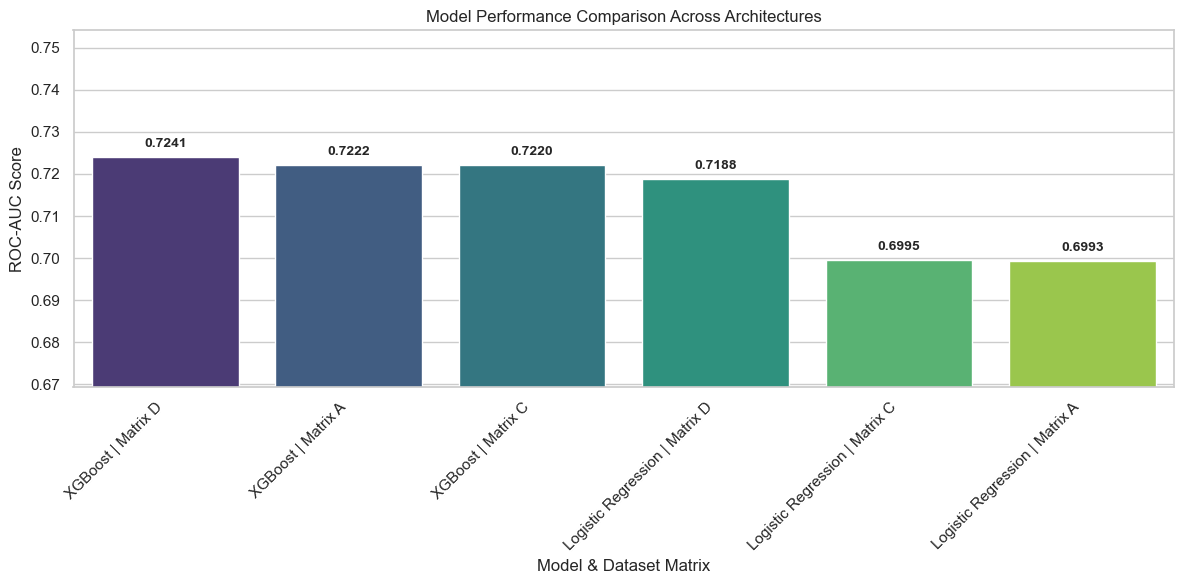

<Figure size 640x480 with 0 Axes>

In [184]:
# ROC-AUC
# ________________________________________

plt.figure(figsize=(12, 6))

# Prepare and sort data

plot = comparison.sort_values("ROC_AUC"
                              
                              , ascending=False).reset_index(drop=True)

plot["Label"] = plot["Model"] + " | " + plot["Dataset"]

# Using a color gradient palette

palette = sns.color_palette("viridis", n_colors=len(plot))

ax = sns.barplot(data=plot,x="Label"
                 
                 ,y="ROC_AUC",palette=palette)

# Adding exact score labels on top of each bar

for p in ax.patches:
    
    ax.annotate(f'{p.get_height():.4f}',
                
                (p.get_x() + p.get_width() / 2., p.get_height()),
                
                ha='center', va='bottom',
                
                fontsize=10, fontweight='bold',
                
                xytext=(0, 5), textcoords='offset points')

# Focus the y-axis to highlight the performance gap

plt.ylim(plot["ROC_AUC"].min() - 0.03, plot["ROC_AUC"].max() + 0.03)

# Formatting
plt.xticks(rotation=45, ha="right")

plt.ylabel("ROC-AUC Score")

plt.xlabel("Model & Dataset Matrix")

plt.title("Model Performance Comparison Across Architectures")

plt.tight_layout()

plt.show()

# SAVE FIGURE

plt.savefig(FIGURE_DIR / "roc_auc_comparison.png", dpi=300, bbox_inches="tight")

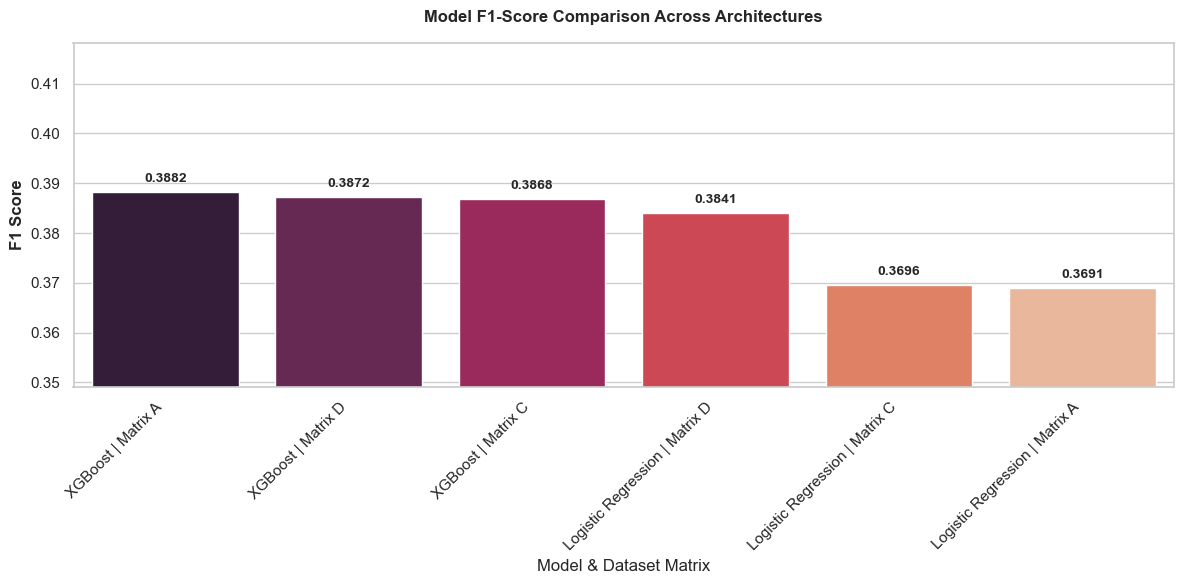

<Figure size 640x480 with 0 Axes>

In [185]:
# F1 Score
# _______________________________________________

plt.figure(figsize=(12, 6))

# Sort by F1 Score descending 

plot = comparison.sort_values("F1", ascending=False).reset_index(drop=True)

plot["Label"] = plot["Model"] + " | " + plot["Dataset"]

# Use a colour

palette = sns.color_palette("rocket", n_colors=len(plot))

ax = sns.barplot(data=plot,x="Label",y="F1",palette=palette)

# Add exact score annotations above each bar

for p in ax.patches:
    
    height = p.get_height()
    
    ax.annotate(f'{height:.4f}', 
                
                (p.get_x() + p.get_width() / 2., height), 
                
                ha='center', va='bottom', 

                fontsize=10, fontweight='bold',

                xytext=(0, 5), textcoords='offset points')

# Zoom Y-axis slightly 

plt.ylim(plot["F1"].min() - 0.02, plot["F1"].max() + 0.03)

# Axis labels & formatting

plt.xticks(rotation=45, ha="right")

plt.ylabel("F1 Score", fontweight="bold")

plt.xlabel("Model & Dataset Matrix")

plt.title("Model F1-Score Comparison Across Architectures",fontweight="bold", pad=15)

plt.tight_layout()

plt.show()

# SAVE FIGURE

plt.savefig(FIGURE_DIR / "f1_score_comparison.png", dpi=300, bbox_inches="tight")

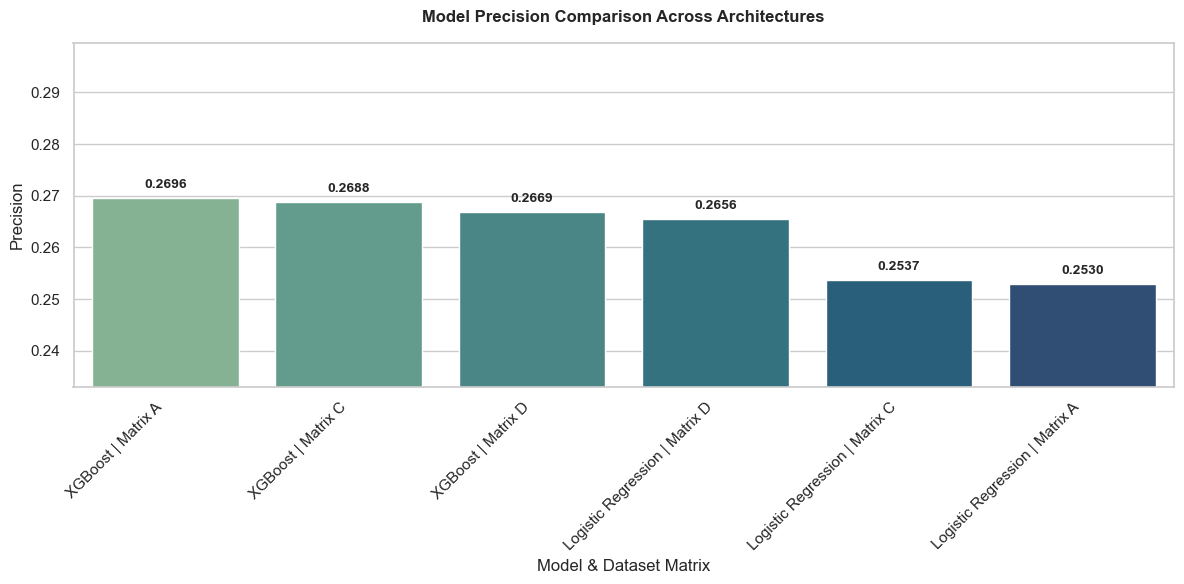

<Figure size 640x480 with 0 Axes>

In [186]:
# Precision

plt.figure(figsize=(12, 6))

# Sort by Precision descending for a structured visual hierarchy

plot = comparison.sort_values("Precision", ascending=False).reset_index(drop=True)

plot["Label"] = plot["Model"] + " | " + plot["Dataset"]

# Use a color

palette = sns.color_palette("crest", n_colors=len(plot))

ax = sns.barplot(data=plot,x="Label",y="Precision",palette=palette)

# Add exact score annotations above each bar

for p in ax.patches:
    
    height = p.get_height()
    
    ax.annotate(f'{height:.4f}', 
                
                (p.get_x() + p.get_width() / 2., height), 
                
                ha='center', va='bottom', 

                fontsize=10, fontweight='bold',

                xytext=(0, 5), textcoords='offset points')

# Zoom Y-axis 

plt.ylim(plot["Precision"].min() - 0.02, plot["Precision"].max() + 0.03)

# Axis labels & formatting

plt.xticks(rotation=45, ha="right")

plt.ylabel("Precision")

plt.xlabel("Model & Dataset Matrix")

plt.title("Model Precision Comparison Across Architectures", fontweight="bold", pad=15)

plt.tight_layout()

plt.show()

# SAVE FIGURE

plt.savefig(FIGURE_DIR / "precision_comparison.png", dpi=300, bbox_inches="tight")

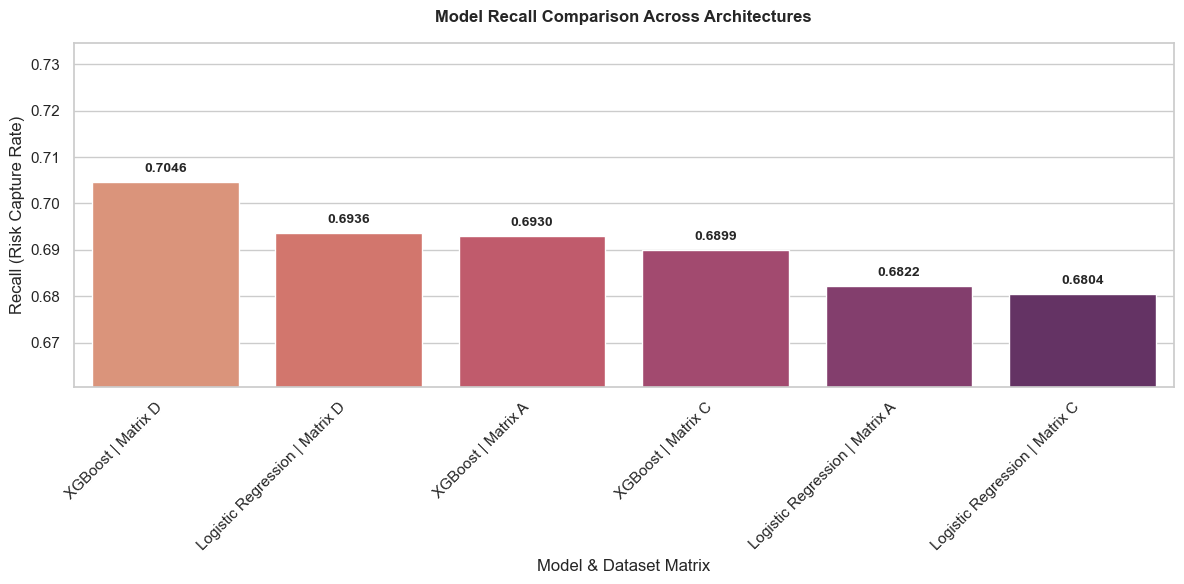

<Figure size 640x480 with 0 Axes>

In [187]:
# Set a crisp whitegrid background

plt.figure(figsize=(12, 6))

# Sort by Recall descending 

plot = comparison.sort_values("Recall", ascending=False).reset_index(drop=True)

plot["Label"] = plot["Model"] + " | " + plot["Dataset"]

# Use a bold palette 

palette = sns.color_palette("flare", n_colors=len(plot))

ax = sns.barplot(data=plot,x="Label",y="Recall",palette=palette)

# Add exact score annotations above each bar

for p in ax.patches:
    
    height = p.get_height()
    
    ax.annotate(f'{height:.4f}', 
                
                (p.get_x() + p.get_width() / 2., height),
                
                ha='center', va='bottom',

                fontsize=10, fontweight='bold', 

                xytext=(0, 5), textcoords='offset points')

# Zoom Y-axis 

plt.ylim(plot["Recall"].min() - 0.02, plot["Recall"].max() + 0.03)

# Axis labels & formatting

plt.xticks(rotation=45, ha="right")

plt.ylabel("Recall (Risk Capture Rate)")

plt.xlabel("Model & Dataset Matrix")

plt.title("Model Recall Comparison Across Architectures", fontweight="bold", pad=15)

plt.tight_layout()

plt.show()

# SAVE FIGURE

plt.savefig(FIGURE_DIR / "recall_comparison.png", dpi=300, bbox_inches="tight")

In [200]:
# EXECUTIVE SUMMARY
# ____________________________________

summary = pd.DataFrame({

    "Total Models":[comparison["Model"].nunique()],

    "Feature Sets":[comparison["Dataset"].nunique()],

    "Experiments":[len(comparison)],

    "Champion Model":[champion["Model"]],

    "Champion Dataset":[champion["Dataset"]],

    "Champion ROC_AUC":[round(champion["ROC_AUC"],4)]})

display(summary)

,Total Models,Feature Sets,Experiments,Champion Model,Champion Dataset,Champion ROC_AUC
0,2,3,6,XGBoost,Matrix D,0.7241


In [214]:
# convert spase to Numpy

y_train = y_train.ravel()

y_test = y_test.ravel()

In [29]:
# Save the Target 

np.save(FEATURE_STORE_DIR / "y_train.npy",y_train)

np.save(FEATURE_STORE_DIR / "y_test.npy",y_test)

joblib.dump(y_train,FEATURE_STORE_DIR / "y_train.pkl")

logger.info("Target arrays saved successfully.")

2026-07-24 23:21:37,645 | INFO | Target arrays saved successfully.
